In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/LoanPoolDataset_Detailed (1).csv')
df.loc[df['Deal_Number']=='BT1','Deal_Number']=10

df['Deal_Number']=df['Deal_Number'].astype(int)
df.head()

,Original Interest Rate_mean,Original Interest Rate_q25,Original Interest Rate_q75,Original Interest Rate_min,Original Interest Rate_max,Current Interest Rate_mean,Current Interest Rate_q25,Current Interest Rate_q75,Current Interest Rate_min,Current Interest Rate_max,...,P_0_30,P_31_60,P_61_90,P_90plus,Pool,Month,Deal_Type,Deal_Number,Group,Deal_Year
0,3.886249,3.625,4.0,2.75,6.375,3.860407,3.625,4.0,2.75,6.125,...,1.0,0.0,0.0,0.0,CAS_2013-C01_G1_012022,2022-01,C,1,G1,2013
1,3.886249,3.625,4.0,2.75,6.375,3.855684,3.625,4.0,2.75,6.125,...,1.0,0.0,0.0,0.0,CAS_2013-C01_G1_012023,2023-01,C,1,G1,2013
2,3.886249,3.625,4.0,2.75,6.375,3.859796,3.625,4.0,2.75,6.125,...,1.0,0.0,0.0,0.0,CAS_2013-C01_G1_022022,2022-02,C,1,G1,2013
3,3.886249,3.625,4.0,2.75,6.375,3.855561,3.625,4.0,2.75,6.125,...,1.0,0.0,0.0,0.0,CAS_2013-C01_G1_022023,2023-02,C,1,G1,2013
4,3.886249,3.625,4.0,2.75,6.375,3.859657,3.625,4.0,2.75,6.125,...,1.0,0.0,0.0,0.0,CAS_2013-C01_G1_032022,2022-03,C,1,G1,2013


# data exploration

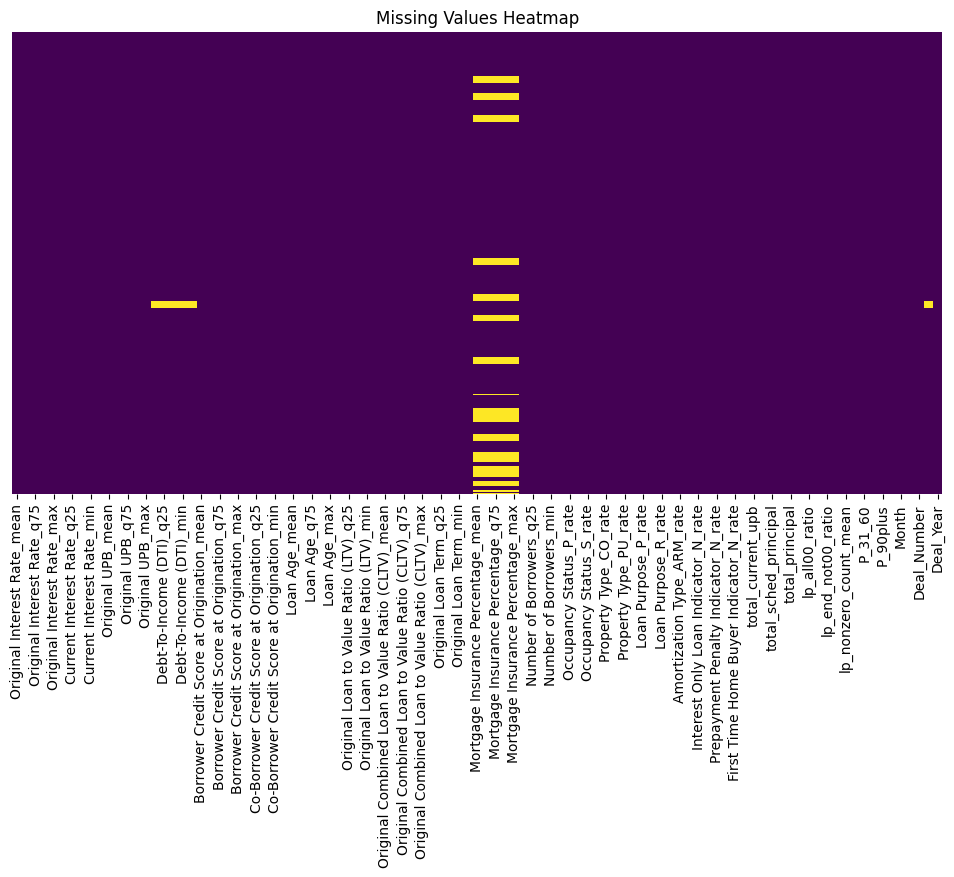

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

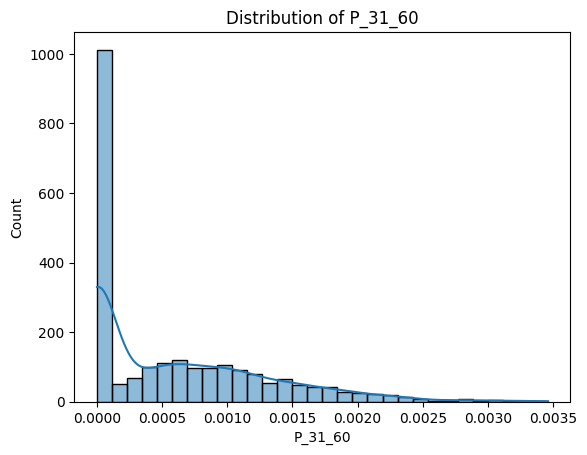

In [ ]:
sns.histplot(df["P_31_60"], bins=30, kde=True)
plt.title("Distribution of P_31_60")
plt.show()


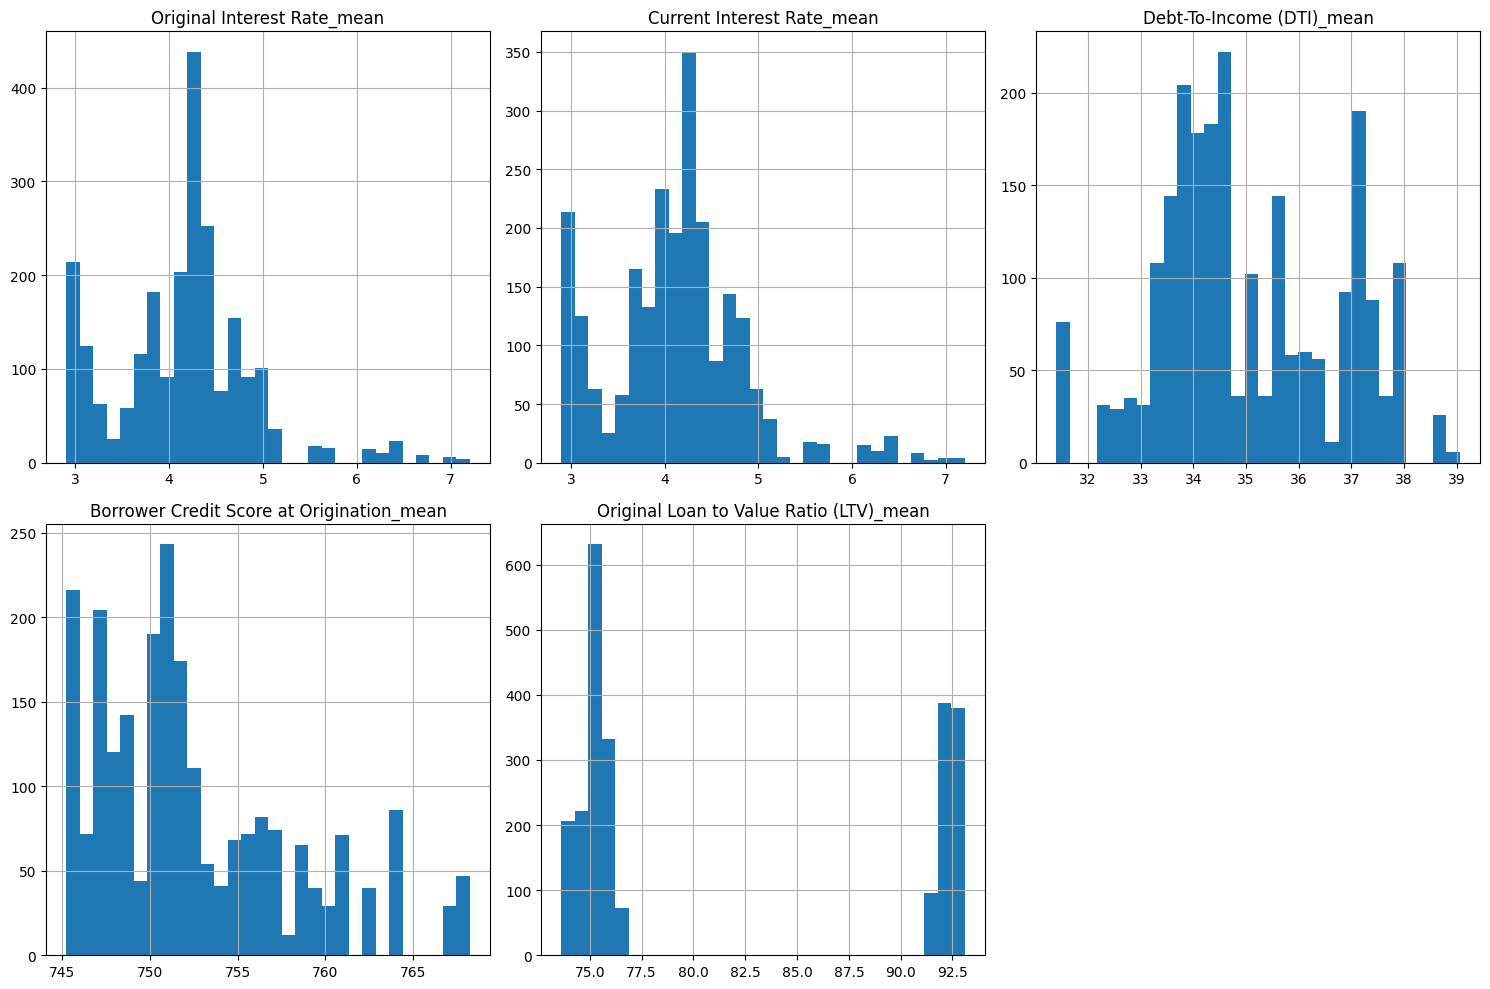

In [ ]:
features = [
    "Original Interest Rate_mean", "Current Interest Rate_mean",
    "Debt-To-Income (DTI)_mean", "Borrower Credit Score at Origination_mean",
    "Original Loan to Value Ratio (LTV)_mean"
]

df[features].hist(figsize=(15, 10), bins=30, layout=(2, 3))
plt.tight_layout()
plt.show()

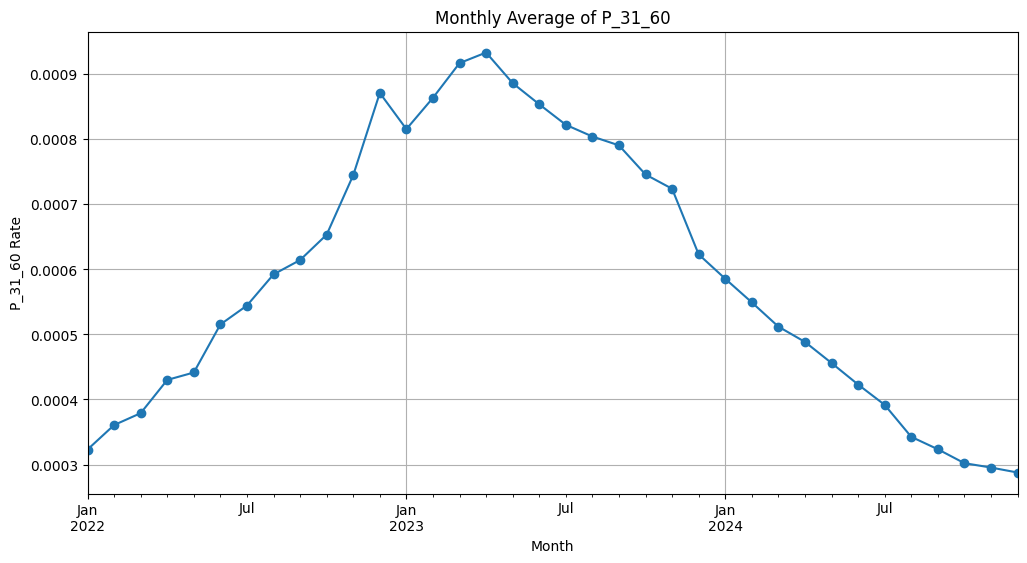

In [ ]:
df['Month'] = pd.to_datetime(df['Month'])
monthly_avg = df.groupby(df['Month'].dt.to_period("M"))['P_31_60'].mean()

monthly_avg.plot(figsize=(12, 6), marker='o')
plt.title("Monthly Average of P_31_60")
plt.ylabel("P_31_60 Rate")
plt.xlabel("Month")
plt.grid(True)
plt.show()


#train test split

In [ ]:
df=pd.read_csv('/content/LoanPoolDataset_Detailed (1).csv')
df.loc[df['Deal_Number']=='BT1','Deal_Number']=10

df['Deal_Number']=df['Deal_Number'].astype(int)


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# 1. 转换 Month 列为时间格式
df['Month'] = pd.to_datetime(df['Month'])

# 2. 提取目标列
target_col = 'P_31_60'

# 3. 删除其他 P_ 开头的列 + Pool
drop_p_cols = [col for col in df.columns if col.startswith('P_') and col != target_col]
drop_p_cols.append('Pool')
df = df.drop(columns=drop_p_cols)

# 4. 只处理这两个分类列（避免你 cat_cols 和后面不一致）
cat_cols = ['Deal_Type', 'Group']

# 5. 填补缺失值
df[cat_cols] = df[cat_cols].fillna('missing')

# 6. 独热编码
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_encoded = encoder.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(X_cat_encoded, columns=encoder.get_feature_names_out(cat_cols), index=df.index)

# 7. 删除原始分类列并拼接
df_encoded = df.drop(columns=cat_cols).copy()
df_encoded = pd.concat([df_encoded, encoded_df], axis=1)

# 8. 划分训练集和预测集
df_train = df_encoded[df_encoded['Month'].dt.year.isin([2022, 2023])].copy()
df_pred = df_encoded[df_encoded['Month'].dt.year == 2024].copy()

# 9. 提取 X 和 y
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

X_pred = df_pred.drop(columns=[target_col])
y_pred = df_pred[target_col]

# 10. 均值填充（用训练集的均值）
X_train_filled = X_train.fillna(X_train.mean())
X_pred_filled = X_pred.fillna(X_train.mean())

X_train_filled['Month_Num'] = df_train['Month'].dt.month
X_pred_filled['Month_Num'] = df_pred['Month'].dt.month

<ipython-input-148-fda12325eecf>:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_filled['Month_Num'] = df_train['Month'].dt.month
<ipython-input-148-fda12325eecf>:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_pred_filled['Month_Num'] = df_pred['Month'].dt.month


In [ ]:
X_train_filled.head()

,Original Interest Rate_mean,Original Interest Rate_q25,Original Interest Rate_q75,Original Interest Rate_min,Original Interest Rate_max,Current Interest Rate_mean,Current Interest Rate_q25,Current Interest Rate_q75,Current Interest Rate_min,Current Interest Rate_max,...,Deal_Number,Deal_Year,Deal_Type_C,Deal_Type_HRP,Deal_Type_R,Deal_Type_S,Group_G1,Group_G2,Group_missing,Month_Num
0,3.886249,3.625,4.0,2.75,6.375,3.860407,3.625,4.0,2.75,6.125,...,1,2013,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,3.886249,3.625,4.0,2.75,6.375,3.855684,3.625,4.0,2.75,6.125,...,1,2013,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
2,3.886249,3.625,4.0,2.75,6.375,3.859796,3.625,4.0,2.75,6.125,...,1,2013,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2
3,3.886249,3.625,4.0,2.75,6.375,3.855561,3.625,4.0,2.75,6.125,...,1,2013,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2
4,3.886249,3.625,4.0,2.75,6.375,3.859657,3.625,4.0,2.75,6.125,...,1,2013,1.0,0.0,0.0,0.0,1.0,0.0,0.0,3


#Scaling

In [ ]:
# 1. 备份 Month 列，供后续可视化用
month_train = X_train_filled['Month'].copy()
month_pred = X_pred_filled['Month'].copy()

# 2. 从 X 中删除它
X_train_filled = X_train_filled.drop(columns=['Month'])
X_pred_filled = X_pred_filled.drop(columns=['Month'])

# 3. 标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_pred_scaled = scaler.transform(X_pred_filled)


#Modeling

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# 建模
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# 预测
y_pred_ridge = ridge.predict(X_pred_scaled)

# 评估
print("R2:", r2_score(y_pred, y_pred_ridge))
print("MSE:", mean_squared_error(y_pred, y_pred_ridge))


R2: -1.3619456803181405
MSE: 5.561802103309124e-07


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 建模
rf = RandomForestRegressor(n_estimators=200,max_depth=18, random_state=42)
rf.fit(X_train_scaled, y_train)

# 预测
y_pred_rf = rf.predict(X_pred_scaled)

# 评估
print("🌲 Random Forest Results:")
print("MSE:", mean_squared_error(y_pred, y_pred_rf))
print("R^2:", r2_score(y_pred, y_pred_rf))

# 特征重要性
import pandas as pd
rf_importance = pd.DataFrame({
    'feature': X_train_filled.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 20 Important Features (RF):")
print(rf_importance.head(20))


🌲 Random Forest Results:
MSE: 1.373550463686497e-07
R^2: 0.4166905754390188

Top 20 Important Features (RF):
                                          feature  importance
89                            lp_has_02plus_ratio    0.422981
84                                total_principal    0.180104
83                        total_unsched_principal    0.067246
25   Co-Borrower Credit Score at Origination_mean    0.052861
20      Borrower Credit Score at Origination_mean    0.027306
32                                   Loan Age_q75    0.020160
30                                  Loan Age_mean    0.019766
34                                   Loan Age_max    0.017372
87                                 lp_end00_ratio    0.013327
86                                 lp_all00_ratio    0.010472
5                      Current Interest Rate_mean    0.008278
24       Borrower Credit Score at Origination_max    0.008170
88                             lp_end_not00_ratio    0.008070
12                     

In [ ]:
from xgboost import XGBRegressor

# 建模
xgb = XGBRegressor(n_estimators=180, learning_rate=0.01, max_depth=7, random_state=42)
xgb.fit(X_train_scaled, y_train)

# 预测
y_pred_xgb = xgb.predict(X_pred_scaled)

# 评估
print("🚀 XGBoost Results:")
print("MSE:", mean_squared_error(y_pred, y_pred_xgb))
print("R^2:", r2_score(y_pred, y_pred_xgb))

# 特征重要性
xgb_importance = pd.DataFrame({
    'feature': X_train_filled.columns,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 20 Important Features (XGB):")
print(xgb_importance.head(20))


🚀 XGBoost Results:
MSE: 1.0239910148017947e-07
R^2: 0.5651389407298979

Top 20 Important Features (XGB):
                                              feature  importance
89                                lp_has_02plus_ratio    0.194256
84                                    total_principal    0.145086
25       Co-Borrower Credit Score at Origination_mean    0.056750
32                                       Loan Age_q75    0.047049
83                            total_unsched_principal    0.042562
77             First Time Home Buyer Indicator_Y_rate    0.040318
79                                         loan_count    0.029325
87                                     lp_end00_ratio    0.027212
20          Borrower Credit Score at Origination_mean    0.024245
2                          Original Interest Rate_q75    0.023453
55                           Number of Borrowers_mean    0.023215
27        Co-Borrower Credit Score at Origination_q75    0.020131
34                                   

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score


mlp = MLPRegressor(
    hidden_layer_sizes=(32, 32),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=1000,
    random_state=42
)
from sklearn.preprocessing import StandardScaler

# y 是一维的，要 reshape 成二维
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()  # 再展平为 1D

# 训练
mlp.fit(X_train_scaled, y_train_scaled)

# 预测后再 inverse transform 回原尺度
y_pred_scaled = mlp.predict(X_pred_scaled)
y_pred_mlp = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()


print("MLP with Y-scaling:")
print("MSE:", mean_squared_error(y_pred, y_pred_mlp))
print("R²:", r2_score(y_pred, y_pred_mlp))


MLP with Y-scaling:
MSE: 5.174508932018558e-07
R²: -1.1974728321378345


#analysis

In [ ]:
# 1. 读取原始数据（只为获取 Pool 列）
raw_df = pd.read_csv("/content/LoanPoolDataset_Detailed (1).csv")
raw_df['Month'] = pd.to_datetime(raw_df['Month'])

# 2. 提取 2024 年的 Pool 信息，并补回 df_pred
pool_2024 = raw_df[raw_df['Month'].dt.year == 2024][['Month', 'Pool']].reset_index(drop=True)
df_pred = df_pred.reset_index(drop=True)
df_pred['Pool'] = pool_2024['Pool']
df_pred['Month'] = pool_2024['Month']  # 保证 Month 也同步正确

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_pool_group_trend(pool_prefix, df_pred, y_pred_xgb):
    """
    画出某一 Pool 前缀在 2024 年的 P_31_60 实际值与预测值对比折线图

    Parameters:
    - pool_prefix: str, 比如 'CAS_2014-C01_G1'
    - df_pred: DataFrame, 包含 2024 年预测数据和原始 Pool 信息
    - y_pred_xgb: array, 你已经预测出来的 XGBoost 结果（索引应与 df_pred 对齐）
    """

    # 1. 拷贝 df_pred 并加上预测值
    df_plot = df_pred.copy()
    df_plot['XGB_Pred'] = y_pred_xgb

    # 2. 筛选 Pool 前缀匹配的行（该组所有月份）
    df_plot = df_plot[df_plot['Pool'].str.contains(pool_prefix)]

    # 3. 按月份聚合实际和预测值
    df_monthly = df_plot.groupby('Month')[['P_31_60', 'XGB_Pred']].mean().reset_index()

    # 4. 排序并画图
    df_monthly = df_monthly.sort_values('Month')

    plt.figure(figsize=(12, 6))
    plt.plot(df_monthly['Month'], df_monthly['P_31_60'], label='Actual', marker='o')
    plt.plot(df_monthly['Month'], df_monthly['XGB_Pred'], label='Predicted (XGBoost)', marker='x')
    plt.title(f"2024 Monthly Trend: {pool_prefix}")
    plt.xlabel("Month")
    plt.ylabel("P_31_60 Rate (avg)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


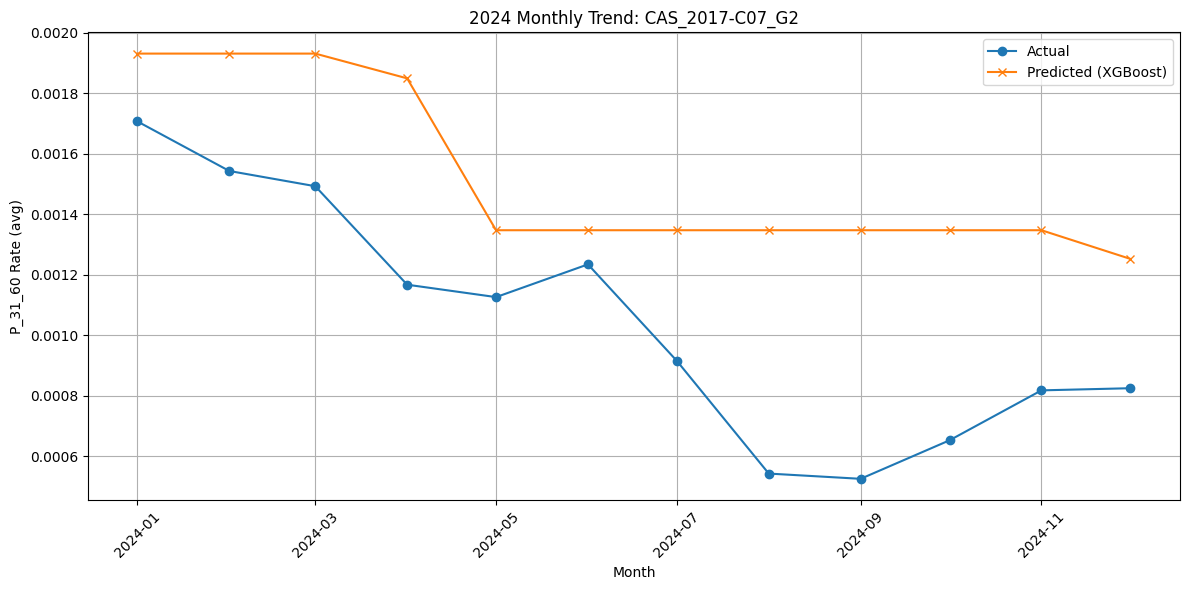

In [ ]:
plot_pool_group_trend('CAS_2017-C07_G2', df_pred, y_pred_xgb)


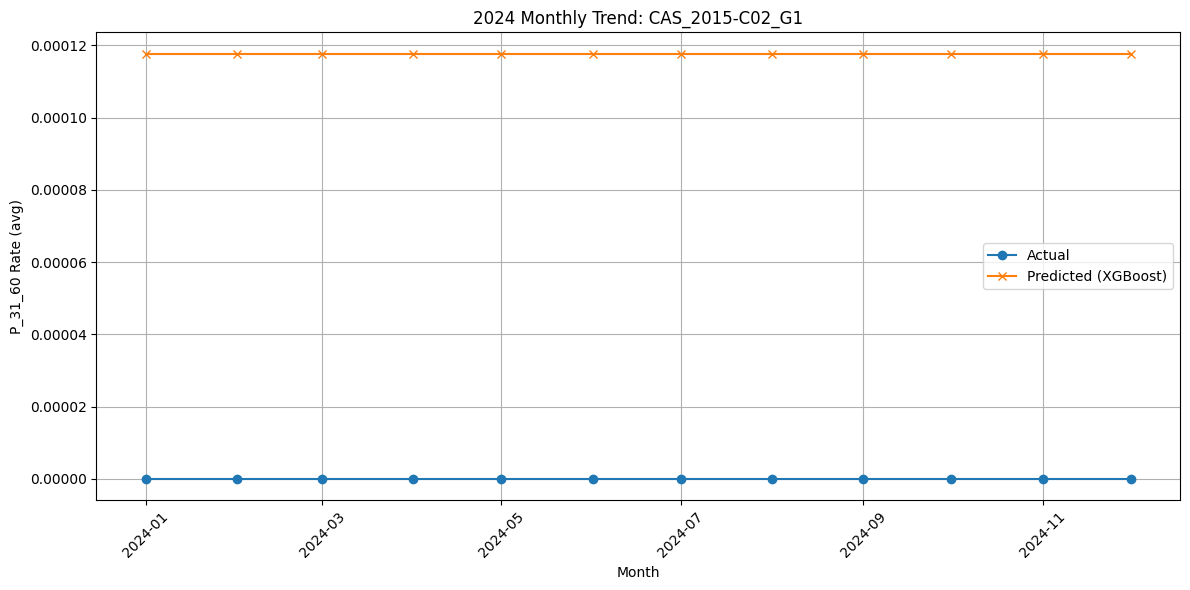

In [ ]:
plot_pool_group_trend('CAS_2015-C02_G1', df_pred, y_pred_xgb)

In [ ]:
def find_top_pool_groups(df_pred, min_months=2):
    pool_groups = df_pred['Pool'].str.extract(r'(CAS_\d{4}-C\d{2}_G\d)')[0]
    df_temp = df_pred.copy()
    df_temp['Pool_Group'] = pool_groups
    counts = df_temp.groupby('Pool_Group')['Month'].nunique()
    top_groups = counts[counts >= min_months].sort_values(ascending=False)
    return top_groups
top_groups = find_top_pool_groups(df_pred, min_months=6)
print(top_groups.head())

Pool_Group
CAS_2015-C02_G1    12
CAS_2017-C07_G2    12
CAS_2015-C01_G1    12
CAS_2015-C04_G1    12
CAS_2015-C03_G1    12
Name: Month, dtype: int64


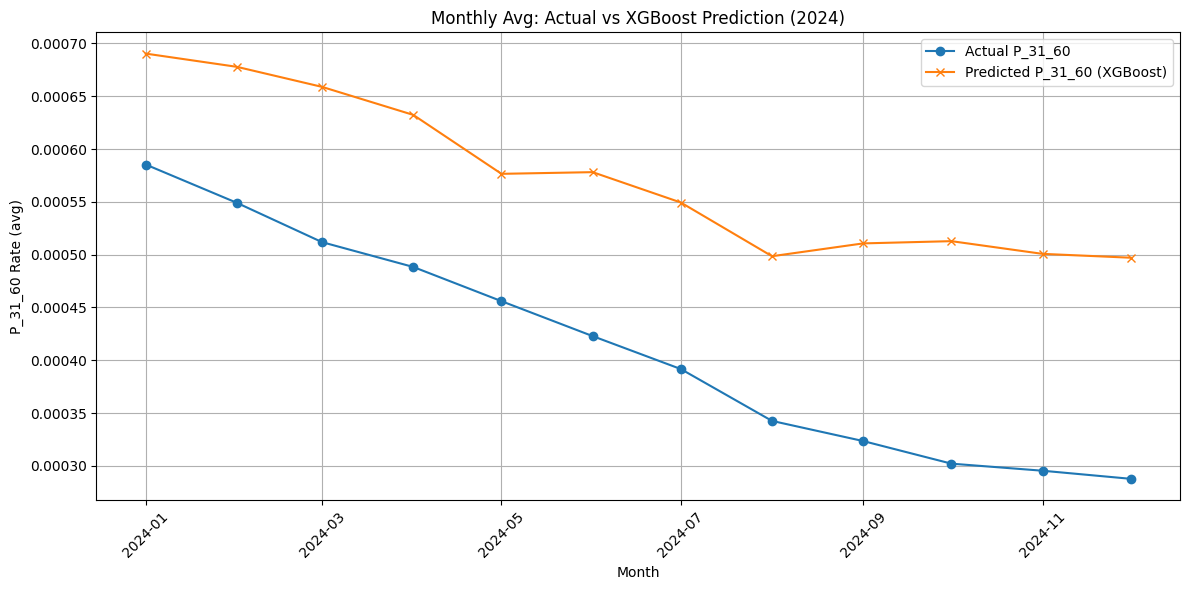

In [ ]:
import matplotlib.pyplot as plt

# 创建 DataFrame 包含预测值
df_pred_with_y = df_pred.copy()
df_pred_with_y['XGB_Pred'] = y_pred_xgb

# 按月份计算真实值和预测值的平均值
monthly_avg = df_pred_with_y.groupby('Month')[['P_31_60', 'XGB_Pred']].mean().reset_index()

# 画图
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg['Month'], monthly_avg['P_31_60'], marker='o', label='Actual P_31_60')
plt.plot(monthly_avg['Month'], monthly_avg['XGB_Pred'], marker='x', label='Predicted P_31_60 (XGBoost)')
plt.title("Monthly Avg: Actual vs XGBoost Prediction (2024)")
plt.xlabel("Month")
plt.ylabel("P_31_60 Rate (avg)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-174-4c6ea3504bfd>:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')[[feature, 'Actual', 'Predicted']].mean()
<ipython-input-174-4c6ea3504bfd>:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')[[feature, 'Actual', 'Predicted']].mean()
<ipython-input-174-4c6ea3504bfd>:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('

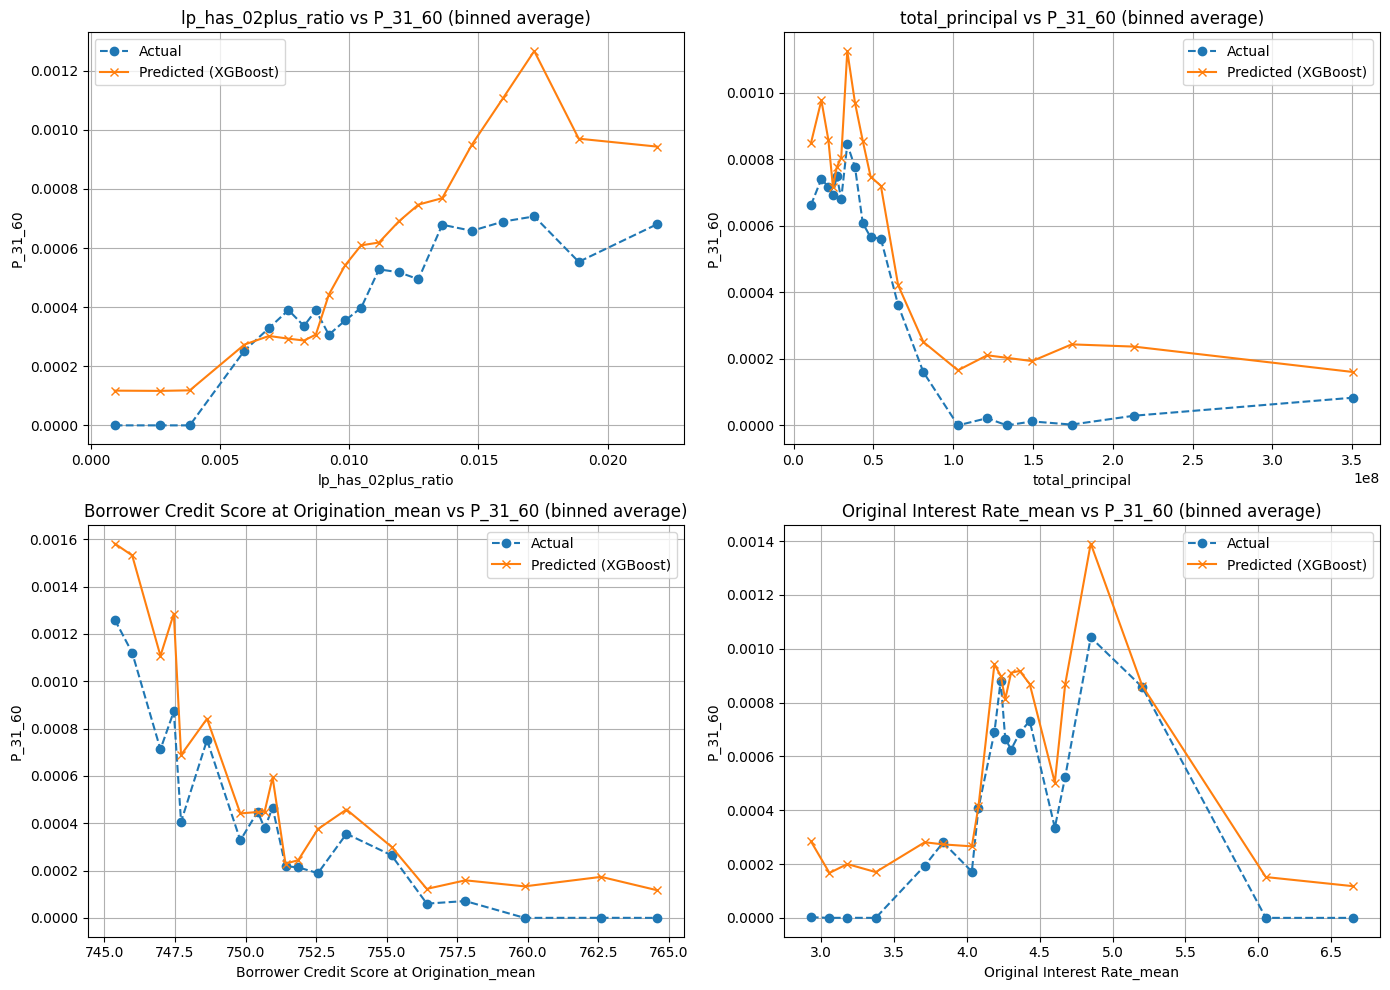

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 要分析的特征
features_to_plot = [
    'lp_has_02plus_ratio',
    'total_principal',
    'Borrower Credit Score at Origination_mean',
    'Original Interest Rate_mean'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # 取出特征、真实值、预测值
    x = X_pred_filled[feature]
    actual = y_pred
    pred = y_pred_xgb

    # 分桶
    df_plot = pd.DataFrame({feature: x, 'Actual': actual, 'Predicted': pred})
    df_plot['bin'] = pd.qcut(df_plot[feature], q=20, duplicates='drop')  # 分成10个分位区间
    grouped = df_plot.groupby('bin')[[feature, 'Actual', 'Predicted']].mean()

    # 画折线图
    axes[i].plot(grouped[feature], grouped['Actual'], label='Actual', linestyle='--', marker='o')
    axes[i].plot(grouped[feature], grouped['Predicted'], label='Predicted (XGBoost)', linestyle='-', marker='x')

    axes[i].set_title(f'{feature} vs P_31_60 (binned average)')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('P_31_60')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()


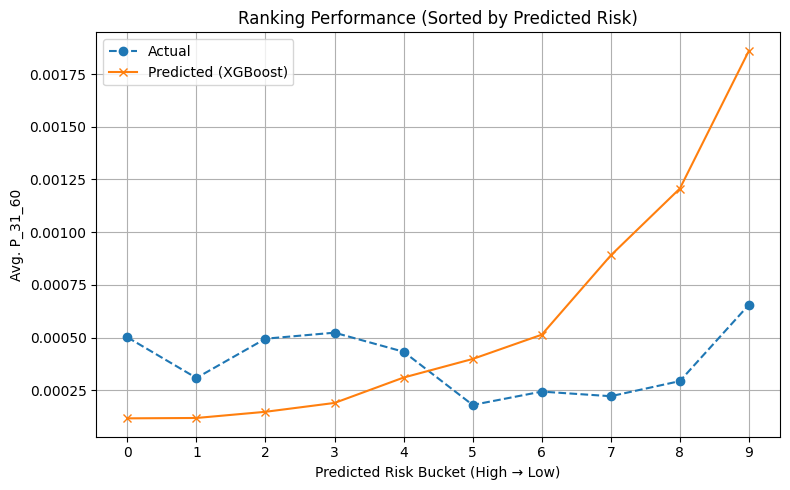

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 创建 DataFrame 并排序
df_rank = df_pred.copy()
df_rank['XGB_Pred'] = y_pred_xgb
df_rank['Actual'] = y_pred

# 按预测值排序并分成10组（decile）
df_rank['bucket'] = pd.qcut(df_rank['XGB_Pred'], q=10, labels=False, duplicates='drop')

# 分组取平均
ranking_plot = df_rank.groupby('bucket')[['Actual', 'XGB_Pred']].mean().reset_index()

# 画图
plt.figure(figsize=(8, 5))
plt.plot(ranking_plot['bucket'], ranking_plot['Actual'], label='Actual', marker='o', linestyle='--')
plt.plot(ranking_plot['bucket'], ranking_plot['XGB_Pred'], label='Predicted (XGBoost)', marker='x', linestyle='-')
plt.title("Ranking Performance (Sorted by Predicted Risk)")
plt.xlabel("Predicted Risk Bucket (High → Low)")
plt.ylabel("Avg. P_31_60")
plt.xticks(ranking_plot['bucket'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
def plot_response_curve(df, feature_name, pred_col='XGB_Pred', true_col='P_31_60', bins=20):
    # 按feature分箱
    df['bin'] = pd.qcut(df[feature_name], q=bins, duplicates='drop')

    # 每个箱子的平均真实值和预测值
    response = df.groupby('bin')[[feature_name, pred_col, true_col]].mean().reset_index()

    # 画图
    plt.figure(figsize=(8, 4))
    plt.plot(response[feature_name], response[true_col], label='Actual', linestyle='--', marker='o')
    plt.plot(response[feature_name], response[pred_col], label='Predicted (XGB)', linestyle='-', marker='x')
    plt.title(f'{feature_name} vs Avg. P_31_60')
    plt.xlabel(feature_name)
    plt.ylabel('Avg. P_31_60')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


<ipython-input-179-12d5813cae13>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  response = df.groupby('bin')[[feature_name, pred_col, true_col]].mean().reset_index()


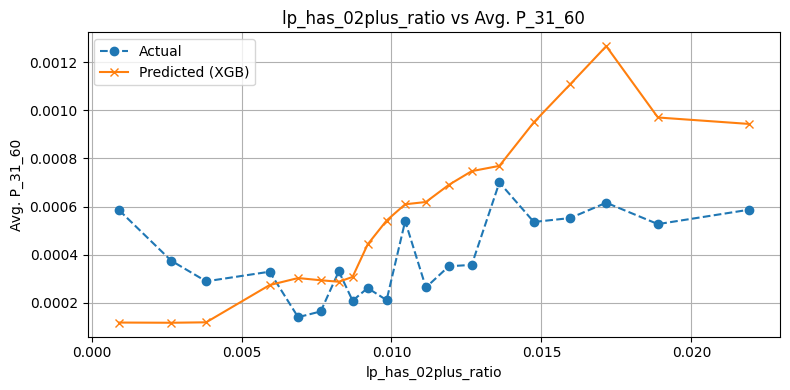

<ipython-input-179-12d5813cae13>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  response = df.groupby('bin')[[feature_name, pred_col, true_col]].mean().reset_index()


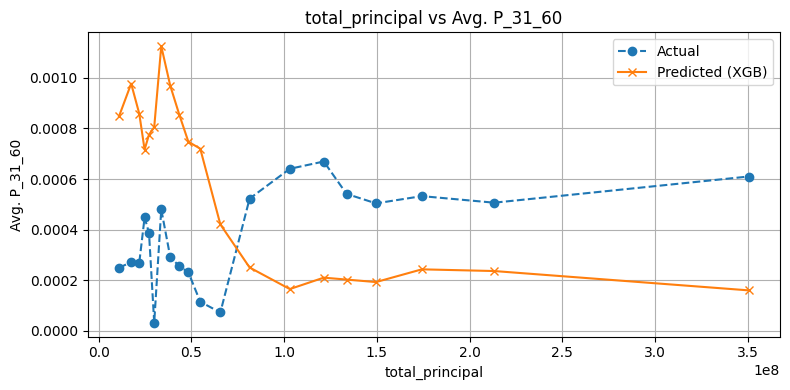

In [ ]:
plot_response_curve(df_pred.assign(XGB_Pred=y_pred_xgb, P_31_60=y_pred),
                    'lp_has_02plus_ratio')

plot_response_curve(df_pred.assign(XGB_Pred=y_pred_xgb, P_31_60=y_pred),
                    'total_principal')


<ipython-input-188-8ed2f1051820>:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby(['loan_size_bucket', 'incentive_group'])[['XGB_Pred', 'Actual']].mean().reset_index()
<ipython-input-188-8ed2f1051820>:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in grouped.groupby('incentive_group'):
<ipython-input-188-8ed2f1051820>:29: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missi

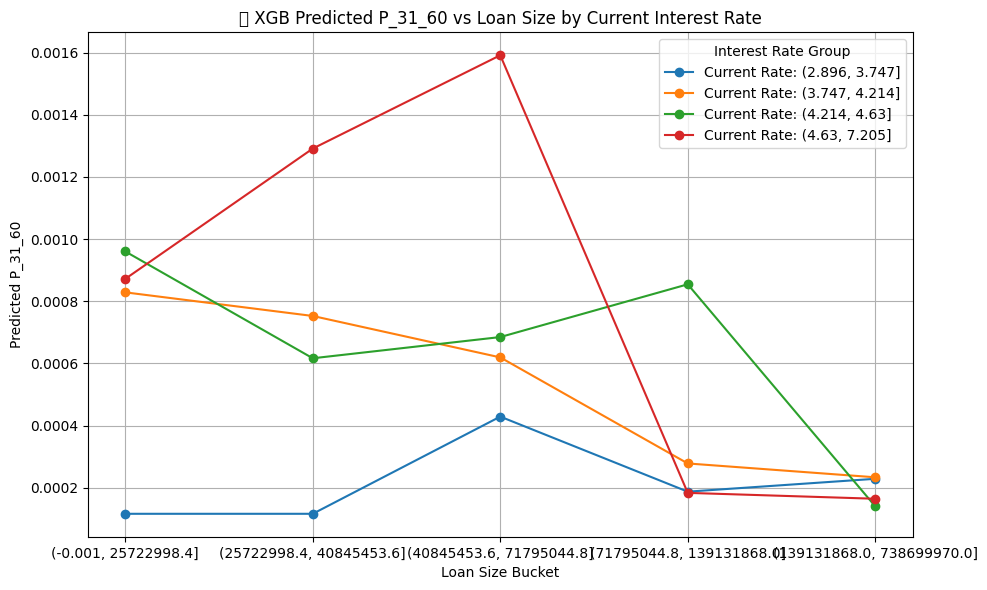

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 建立副本
df_plot = df_pred.copy()
df_plot['XGB_Pred'] = y_pred_xgb
df_plot['Actual'] = y_pred

# 横轴：贷款规模分箱
df_plot['loan_size_bucket'] = pd.qcut(df_plot['total_principal'], q=5, duplicates='drop')

# 激励：当前利率分箱（模拟原图里的 incentive）
df_plot['incentive_group'] = pd.qcut(df_plot['Current Interest Rate_mean'], q=4, duplicates='drop')

# 分组平均值
grouped = df_plot.groupby(['loan_size_bucket', 'incentive_group'])[['XGB_Pred', 'Actual']].mean().reset_index()

# 画图（每条线是一个激励组）
plt.figure(figsize=(10, 6))
for name, group in grouped.groupby('incentive_group'):
    plt.plot(group['loan_size_bucket'].astype(str), group['XGB_Pred'],
             marker='o', label=f"Current Rate: {name}")

plt.title("📈 XGB Predicted P_31_60 vs Loan Size by Current Interest Rate")
plt.xlabel("Loan Size Bucket")
plt.ylabel("Predicted P_31_60")
plt.legend(title="Interest Rate Group")
plt.grid(True)
plt.tight_layout()
plt.show()
